In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [3]:
import numpy as np
import pandas as pd
from time import time

from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

In [4]:
MY_HIDDEN = 128
MY_EPOCH = 500


In [15]:
raw = pd.read_csv('data/translate.csv', header=None)
eng_kor =raw.values.tolist()

In [32]:
e_alpha = [ c for c in 'SEPabcdefghijklmnopqrstuvwxyz' ]
korean = ''.join([data[1] for data in eng_kor])
k_ch =list(set([ch for ch in korean]))
k_ch.sort()
k_alpha= k_ch


In [35]:
alpha =e_alpha + k_alpha
alpha_total_size= len(alpha)
char_to_num= {ch : i for i, ch in enumerate(alpha)}


171

In [36]:
char_to_num.get('c')

5

In [38]:
data = eng_kor[0]
print('인코더 입력(원핫인코딩전):', [char_to_num.get(ch) for ch in data[0]])

['cold', '감기']

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [8]:
input_data = int(input('섭씨온도는?'))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

섭씨온도는?12
화씨온도는  53.6


In [9]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [10]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [14]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수는  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.7

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [20]:
import numpy as np
np.random.seed(707)
noise= np.random.normal(size=100)
noised_scaled_data_F= noise + scaled_data_F
noised_scaled_data_F

array([-0.12999656, -1.00098658,  0.74588256, -0.65425763, -0.83828364,
       -0.15856116,  0.64478399,  0.24721592,  0.76496457,  0.23602857,
       -1.34258172,  2.13763373, -0.21228606,  1.62921893, -0.61609144,
       -0.79028799,  1.82981322, -0.21690961,  1.04268406,  1.54426283,
        0.45351792,  1.36927816, -0.74201387,  1.30709774, -0.47147487,
       -0.92413893,  1.01671909,  0.68056665,  1.66651209,  0.42405459,
        0.749619  , -0.62113971,  1.76961625, -0.40866782, -0.17564897,
        2.0042797 , -0.05539977,  1.09887908,  2.42686042,  0.10418075,
       -0.25080437,  2.56673574, -0.7032777 ,  0.9664513 , -0.41300355,
        2.27178719,  4.37091408, -1.5594156 ,  1.74492319,  1.87857176,
        2.94033711,  0.86667929,  0.42958624,  0.38242015,  1.02478072,
        0.80141138,  0.60626578,  2.55443518,  1.95073867,  1.39670911,
        0.85545055,  1.77057045,  2.90046733,  0.07623283,  0.59179257,
        1.95242021,  0.1199068 ,  1.41420436,  2.58489504,  2.93

In [12]:
model2=Sequential()
model2.add(Dense(units=1, input_shape=(1,)))
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
print(model2.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


In [21]:
hist2= model2.fit(scaled_data_C, noised_scaled_data_F, epochs=1000,
                  verbose=1)

Epoch 1/1000
4/4 [==============================] - 1s 2ms/step - loss: 5.2765 - mae: 1.9006
Epoch 2/1000
4/4 [==============================] - 0s 3ms/step - loss: 5.2321 - mae: 1.8921
Epoch 3/1000
4/4 [==============================] - 0s 4ms/step - loss: 5.2027 - mae: 1.8865
Epoch 4/1000
4/4 [==============================] - 0s 2ms/step - loss: 5.1747 - mae: 1.8812
Epoch 5/1000
4/4 [==============================] - 0s 2ms/step - loss: 5.1505 - mae: 1.8765
Epoch 6/1000
4/4 [==============================] - 0s 3ms/step - loss: 5.1281 - mae: 1.8723
Epoch 7/1000
4/4 [==============================] - 0s 2ms/step - loss: 5.1040 - mae: 1.8678
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 5.0818 - mae: 1.8634
Epoch 9/1000
4/4 [==============================] - 0s 1ms/step - loss: 5.0582 - mae: 1.8589
Epoch 10/1000
4/4 [==============================] - 0s 3ms/step - loss: 5.0358 - mae: 1.8546
Epoch 11/1000
4/4 [==============================] - 0s 0s/step - los

4/4 [==============================] - 0s 0s/step - loss: 3.5626 - mae: 1.5485
Epoch 89/1000
4/4 [==============================] - 0s 2ms/step - loss: 3.5480 - mae: 1.5451
Epoch 90/1000
4/4 [==============================] - 0s 5ms/step - loss: 3.5319 - mae: 1.5416
Epoch 91/1000
4/4 [==============================] - 0s 1ms/step - loss: 3.5162 - mae: 1.5381
Epoch 92/1000
4/4 [==============================] - 0s 3ms/step - loss: 3.5013 - mae: 1.5349
Epoch 93/1000
4/4 [==============================] - 0s 2ms/step - loss: 3.4843 - mae: 1.5309
Epoch 94/1000
4/4 [==============================] - 0s 2ms/step - loss: 3.4666 - mae: 1.5269
Epoch 95/1000
4/4 [==============================] - 0s 3ms/step - loss: 3.4494 - mae: 1.5231
Epoch 96/1000
4/4 [==============================] - 0s 5ms/step - loss: 3.4328 - mae: 1.5194
Epoch 97/1000
4/4 [==============================] - 0s 3ms/step - loss: 3.4170 - mae: 1.5157
Epoch 98/1000
4/4 [==============================] - 0s 2ms/step - loss: 3.

4/4 [==============================] - 0s 2ms/step - loss: 2.4579 - mae: 1.2789
Epoch 175/1000
4/4 [==============================] - 0s 4ms/step - loss: 2.4474 - mae: 1.2763
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.4361 - mae: 1.2732
Epoch 177/1000
4/4 [==============================] - 0s 1ms/step - loss: 2.4275 - mae: 1.2710
Epoch 178/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.4172 - mae: 1.2683
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.4082 - mae: 1.2659
Epoch 180/1000
4/4 [==============================] - 0s 0s/step - loss: 2.3956 - mae: 1.2625
Epoch 181/1000
4/4 [==============================] - 0s 0s/step - loss: 2.3862 - mae: 1.2604
Epoch 182/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.3786 - mae: 1.2585
Epoch 183/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.3690 - mae: 1.2558
Epoch 184/1000
4/4 [==============================] - 0s 3ms/step -

4/4 [==============================] - 0s 668us/step - loss: 1.8259 - mae: 1.1135
Epoch 261/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.8202 - mae: 1.1117
Epoch 262/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.8158 - mae: 1.1104
Epoch 263/1000
4/4 [==============================] - 0s 4ms/step - loss: 1.8109 - mae: 1.1089
Epoch 264/1000
4/4 [==============================] - 0s 0s/step - loss: 1.8062 - mae: 1.1075
Epoch 265/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.8028 - mae: 1.1065
Epoch 266/1000
4/4 [==============================] - 0s 5ms/step - loss: 1.7968 - mae: 1.1047
Epoch 267/1000
4/4 [==============================] - 0s 0s/step - loss: 1.7915 - mae: 1.1030
Epoch 268/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.7893 - mae: 1.1024
Epoch 269/1000
4/4 [==============================] - 0s 4ms/step - loss: 1.7858 - mae: 1.1013
Epoch 270/1000
4/4 [==============================] - 0s 4ms/step

4/4 [==============================] - 0s 2ms/step - loss: 1.5918 - mae: 1.0514
Epoch 347/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5902 - mae: 1.0511
Epoch 348/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5891 - mae: 1.0507
Epoch 349/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5871 - mae: 1.0504
Epoch 350/1000
4/4 [==============================] - 0s 670us/step - loss: 1.5866 - mae: 1.0501
Epoch 351/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5851 - mae: 1.0498
Epoch 352/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5838 - mae: 1.0495
Epoch 353/1000
4/4 [==============================] - 0s 5ms/step - loss: 1.5820 - mae: 1.0491
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5803 - mae: 1.0487
Epoch 355/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.5795 - mae: 1.0486
Epoch 356/1000
4/4 [==============================] - 0s 3ms/st

...

4/4 [==============================] - 0s 6ms/step - loss: 1.3747 - mae: 0.9771
Epoch 605/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3739 - mae: 0.9768
Epoch 606/1000
4/4 [==============================] - 0s 4ms/step - loss: 1.3732 - mae: 0.9765
Epoch 607/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3727 - mae: 0.9763
Epoch 608/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.3719 - mae: 0.9760
Epoch 609/1000
4/4 [==============================] - 0s 0s/step - loss: 1.3711 - mae: 0.9757
Epoch 610/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.3705 - mae: 0.9755
Epoch 611/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.3702 - mae: 0.9755
Epoch 612/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3692 - mae: 0.9751
Epoch 613/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3687 - mae: 0.9749
Epoch 614/1000
4/4 [==============================] - 0s 2ms/step 

4/4 [==============================] - 0s 0s/step - loss: 1.3187 - mae: 0.9557
Epoch 691/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.3183 - mae: 0.9556
Epoch 692/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.3177 - mae: 0.9554
Epoch 693/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.3172 - mae: 0.9552
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3166 - mae: 0.9549
Epoch 695/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.3158 - mae: 0.9546
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3152 - mae: 0.9543
Epoch 697/1000
4/4 [==============================] - 0s 5ms/step - loss: 1.3147 - mae: 0.9541
Epoch 698/1000
4/4 [==============================] - 0s 4ms/step - loss: 1.3143 - mae: 0.9539
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3137 - mae: 0.9537
Epoch 700/1000
4/4 [==============================] - 0s 4ms/step 

4/4 [==============================] - 0s 1ms/step - loss: 1.2775 - mae: 0.9392
Epoch 777/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.2768 - mae: 0.9389
Epoch 778/1000
4/4 [==============================] - 0s 7ms/step - loss: 1.2764 - mae: 0.9388
Epoch 779/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.2759 - mae: 0.9387
Epoch 780/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2755 - mae: 0.9386
Epoch 781/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2753 - mae: 0.9385
Epoch 782/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2746 - mae: 0.9382
Epoch 783/1000
4/4 [==============================] - 0s 177us/step - loss: 1.2747 - mae: 0.9382
Epoch 784/1000
4/4 [==============================] - 0s 7ms/step - loss: 1.2744 - mae: 0.9381
Epoch 785/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.2740 - mae: 0.9380
Epoch 786/1000
4/4 [==============================] - 0s 4ms/st

4/4 [==============================] - 0s 3ms/step - loss: 1.2433 - mae: 0.9276
Epoch 863/1000
4/4 [==============================] - 0s 0s/step - loss: 1.2432 - mae: 0.9276
Epoch 864/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.2426 - mae: 0.9274
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2422 - mae: 0.9272
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2419 - mae: 0.9270
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2416 - mae: 0.9269
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2416 - mae: 0.9269
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2414 - mae: 0.9268
Epoch 870/1000
4/4 [==============================] - 0s 4ms/step - loss: 1.2408 - mae: 0.9266
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2405 - mae: 0.9265
Epoch 872/1000
4/4 [==============================] - 0s 3ms/step 

4/4 [==============================] - 0s 2ms/step - loss: 1.2131 - mae: 0.9168
Epoch 949/1000
4/4 [==============================] - 0s 788us/step - loss: 1.2131 - mae: 0.9169
Epoch 950/1000
4/4 [==============================] - 0s 6ms/step - loss: 1.2128 - mae: 0.9168
Epoch 951/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2126 - mae: 0.9167
Epoch 952/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.2122 - mae: 0.9165
Epoch 953/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2120 - mae: 0.9165
Epoch 954/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.2116 - mae: 0.9164
Epoch 955/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2113 - mae: 0.9162
Epoch 956/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.2110 - mae: 0.9161
Epoch 957/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2107 - mae: 0.9160
Epoch 958/1000
4/4 [==============================] - 0s 2ms/st

In [23]:
hist2.history.keys()

dict_keys(['loss', 'mae'])

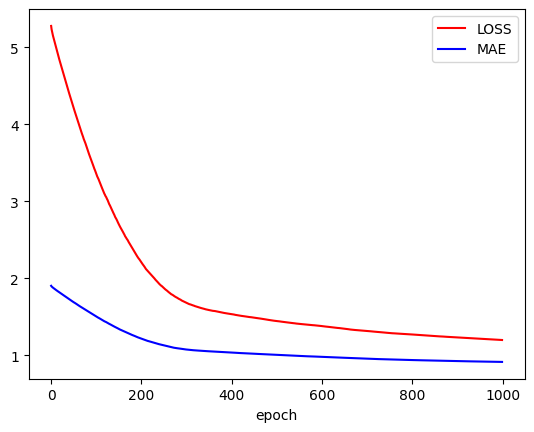

In [24]:
plt.plot(hist2.history['loss'], 'r', label='LOSS')
plt.plot(hist2.history['mae'], 'b', label='MAE')
plt.legend()
plt.xlabel('epoch')
plt.show()

In [25]:
from tensorflow.keras.utils import to_categorical # 분류 분석시 원핫인코딩(추천)
import pandas as pd #원핫인코딩
from tensorflow.keras.models import Sequential, load_model, save_model # 모델 생성, 모델 load
from tensorflow.keras.layers import Dense, Input # 모델에 층을 쌓기 위해서
import numpy as np

In [26]:
# 학습데이터 = 훈련데이터셋
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,3,4,5,6,7,8,9,10]*10)
# 검증데이터, 시험데이터셋
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,3,4,5,6,7,8,9,10])

In [30]:
data= np.array(['aa','bb','ff','bb','df'])
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(data)
labeling_data = le.transform(data)
labeling_data

array([0, 1, 3, 1, 2])

In [32]:
onehot_encoding_data=to_categorical(labeling_data)
onehot_encoding_data

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]], dtype=float32)